In [1]:
# !pip install catboost

# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

import lightgbm as lgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier, Pool
import shap

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/content/drive/MyDrive/data_v2.csv')
df.head(5)

,yqc_cd,year,quarter,ds,gu_cd,gu_nm,dong_cd,dong_nm,dong_area,business_cd,...,SEL_close_avg,wp_total,rp_total,apt_cnt,apt_price,business_cat,wp_missing,rp_missing,apt_cnt_missing,apt_price_missing
0,20191,2019,1,2019-03-01,11110,종로구,11110515,청운효자동,2568432,CS100001,...,48,6476,13047,342,243371110,음식(한식),0,0,1,1
1,20191,2019,1,2019-03-01,11110,종로구,11110515,청운효자동,2568432,CS100002,...,48,6476,13047,342,243371110,음식(중식),0,0,1,1
2,20191,2019,1,2019-03-01,11110,종로구,11110515,청운효자동,2568432,CS100003,...,48,6476,13047,342,243371110,음식(일식),0,0,1,1
3,20191,2019,1,2019-03-01,11110,종로구,11110515,청운효자동,2568432,CS100004,...,48,6476,13047,342,243371110,음식(양식),0,0,1,1
4,20191,2019,1,2019-03-01,11110,종로구,11110515,청운효자동,2568432,CS100005,...,48,6476,13047,342,243371110,음식(빵집),0,0,1,1


### EDA

Step 1. 시계열 패널 데이터 연속성 확인

전체 상권-업종 조합 수: 19018
총 24개 분기가 모두 존재하는 조합의 비율: 74.66%


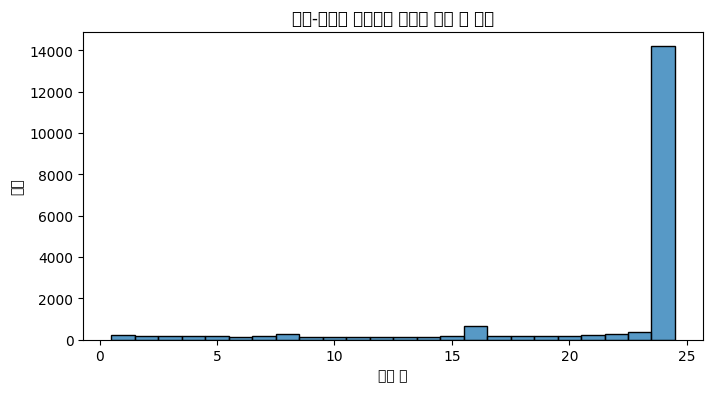

In [4]:
# 행정동(dong_cd)과 업종(business_cd) 조합별로 데이터가 존재하는 분기(yqc_cd) 수 확인
continuity_check = df.groupby(['dong_cd', 'business_cd'])['yqc_cd'].nunique()

print("전체 상권-업종 조합 수:", len(continuity_check))
print("총 24개 분기가 모두 존재하는 조합의 비율: {:.2f}%".format((continuity_check == 24).mean() * 100))

# 24개 분기가 안 되는(중간에 생기거나 폐업한) 조합이 얼마나 되는지 분포 확인
plt.figure(figsize=(8, 4))
sns.histplot(continuity_check, bins=24, discrete=True)
plt.title("상권-업종별 존재하는 데이터 분기 수 분포")
plt.xlabel("분기 수")
plt.ylabel("빈도")
plt.show()

Step 2. 전체 기간 매출 트렌드 (코로나 및 계절성 파악)

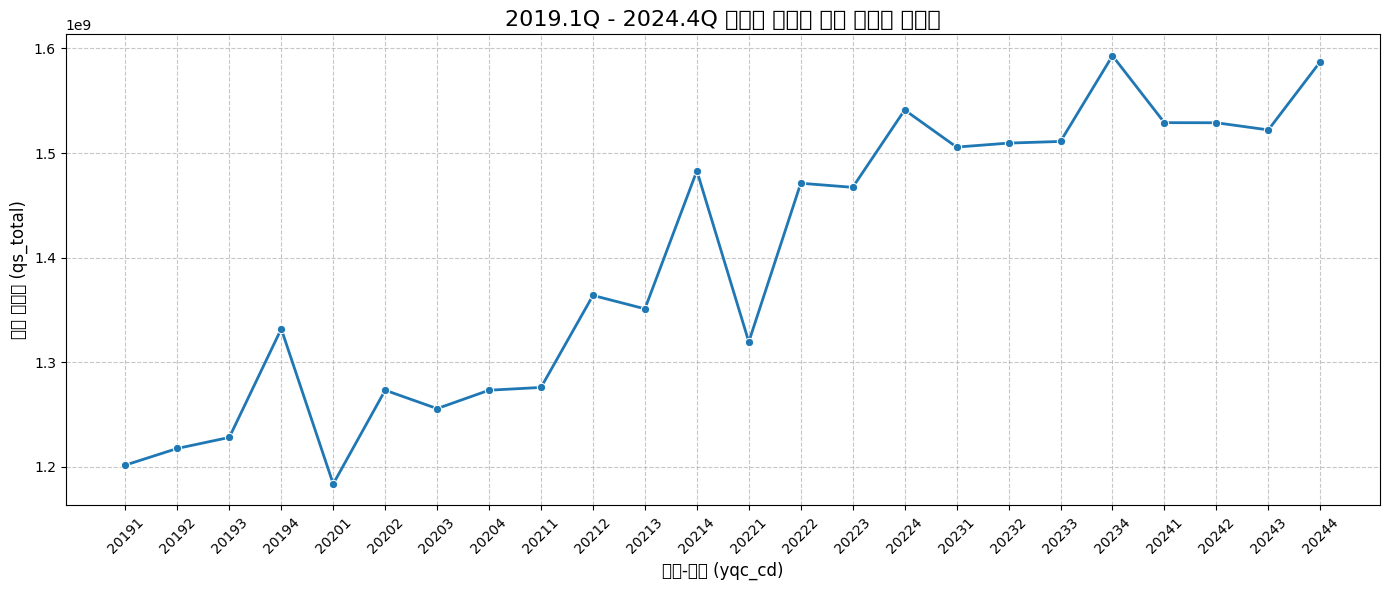

In [5]:
# 분기별 평균 총매출 집계
trend_df = df.groupby('yqc_cd')['qs_total'].mean().reset_index()

plt.figure(figsize=(14, 6))
# yqc_cd를 문자열로 변환하여 x축이 깔끔하게 나오도록 함
sns.lineplot(data=trend_df, x=trend_df['yqc_cd'].astype(str), y='qs_total', marker='o', linewidth=2)

plt.title("2019.1Q - 2024.4Q 서울시 분기별 평균 총매출 트렌드", fontsize=16)
plt.xlabel("연도-분기 (yqc_cd)", fontsize=12)
plt.ylabel("평균 총매출 (qs_total)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Step 3. '성장/유지/위축' 라벨링을 위한 증감률 기준선 찾기

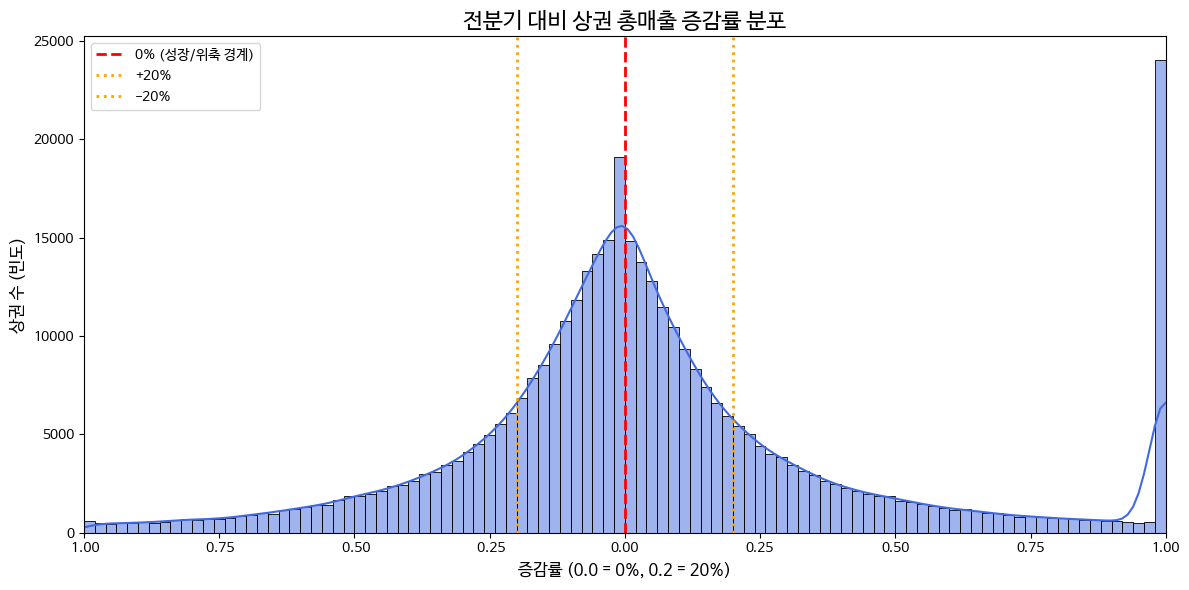

=== 매출 증감률 주요 통계량 ===
count    385205.000000
mean          3.026195
std         665.584359
min          -0.999998
10%          -0.359209
25%          -0.141287
50%           0.002650
75%           0.191246
90%           0.608683
max      371900.740525
Name: growth_rate, dtype: float64


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import warnings

# 경고문 무시
warnings.filterwarnings('ignore')

# OS별 한글 폰트 설정 (로컬 주피터 노트북 기준)
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic') # 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic') # 맥
else:
    plt.rc('font', family='NanumBarunGothic') # 코랩/리눅스

# 1. 데이터 정렬 및 복사 (SettingWithCopyWarning 방지)
df = df.sort_values(['dong_cd', 'business_cd', 'yqc_cd']).copy()

# 2. 전분기 대비 매출 증감률(growth_rate) 계산
df['growth_rate'] = df.groupby(['dong_cd', 'business_cd'])['qs_total'].pct_change()

# 3. 분석을 위한 데이터 정제 (무한대 값과 결측치 제거)
df['growth_rate'] = df['growth_rate'].replace([np.inf, -np.inf], np.nan)
growth_data = df.dropna(subset=['growth_rate'])['growth_rate']

# 4. 히스토그램 시각화 (극단적인 이상치를 제외하고 -100% ~ +100% 구간만 확대)
plt.figure(figsize=(12, 6))
# 데이터가 너무 많을 경우를 대비해 구간(bins)을 세밀하게 나눔
sns.histplot(growth_data.clip(-1, 1), bins=100, kde=True, color='royalblue')

# 기준선 표시 (0%)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='0% (성장/위축 경계)')
plt.axvline(x=0.2, color='orange', linestyle=':', linewidth=2, label='+20%')
plt.axvline(x=-0.2, color='orange', linestyle=':', linewidth=2, label='-20%')

plt.title("전분기 대비 상권 총매출 증감률 분포", fontsize=16)
plt.xlabel("증감률 (0.0 = 0%, 0.2 = 20%)", fontsize=12)
plt.ylabel("상권 수 (빈도)", fontsize=12)
plt.xlim(-1, 1)
plt.legend()
plt.tight_layout()
plt.show()

# 5. 주요 통계량 확인
print("=== 매출 증감률 주요 통계량 ===")
print(growth_data.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

### Feature Engineering

In [7]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

df_feat = df.copy()

# ==========================================
# [1] 기본 스케일 변수 (로그 변환)
# ==========================================
log_cols = ['qs_total', 'fp_total', 'wp_total', 'rp_total', 'apt_price', 'subway_station', 'bus_station']
for col in log_cols:
    df_feat[f'{col}_log'] = np.log1p(df_feat[col])

# ==========================================
# [2] 상권 경쟁력 및 효율 지표
# ==========================================
safe_store_cnt = df_feat['similar_store_cnt'].replace(0, 1)
df_feat['sales_per_store'] = df_feat['qs_total'] / safe_store_cnt
df_feat['store_density'] = df_feat['similar_store_cnt'] / df_feat['dong_area']
df_feat['ATV'] = (df_feat['qs_total'] / df_feat['qsc_total'].replace(0, 1)).fillna(0)

# ==========================================
# [3] 시간대/요일/연령대 비율 (폭넓게 모두 추가!)
# ==========================================
safe_qs_total = df_feat['qs_total'].replace(0, 1)

# 요일 비중
df_feat['sales_weekdays_ratio'] = df_feat['qs_weekdays'] / safe_qs_total
df_feat['sales_weekend_ratio'] = df_feat['qs_weekend'] / safe_qs_total

# 시간대 비중
df_feat['sales_lunch_ratio'] = df_feat['qs_1114'] / safe_qs_total   # 점심
df_feat['sales_afternoon_ratio'] = df_feat['qs_1417'] / safe_qs_total # 오후
df_feat['sales_evening_ratio'] = df_feat['qs_1721'] / safe_qs_total # 저녁 (퇴근/회식)
df_feat['sales_night_ratio'] = df_feat['qs_2124'] / safe_qs_total   # 심야 (유흥)

# 연령대 비중
df_feat['sales_2030_ratio'] = (df_feat['qs_20'] + df_feat['qs_30']) / safe_qs_total # 트렌드 주도층
df_feat['sales_3050_ratio'] = (df_feat['qs_30'] + df_feat['qs_40'] + df_feat['qs_50']) / safe_qs_total # 머니 파워 (직장인/가족)
df_feat['sales_60_ratio'] = df_feat['qs_60'] / safe_qs_total # 시니어

# ==========================================
# [4] 인프라 지표
# ==========================================
df_feat['is_univ'] = (df_feat['university'] > 0).astype(int)
df_feat['edu_cnt'] = df_feat['kindergarden'] + df_feat['ele_school'] + df_feat['mid_school'] + df_feat['high_school']
df_feat['traffic_score'] = (df_feat['subway_station_log'] * 3) + df_feat['bus_station_log']

In [8]:
# ==========================================
# [5] 상권 특성 클러스터링 (K-Means)
# ==========================================
# 클러스터링에 사용할 비율 데이터들만 추출
cluster_features = [
    'sales_weekdays_ratio', 'sales_weekend_ratio',
    'sales_lunch_ratio', 'sales_evening_ratio', 'sales_night_ratio',
    'sales_2030_ratio', 'sales_3050_ratio'
]

# K-Means는 거리를 기반으로 하므로 스케일링 필수
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_feat[cluster_features].fillna(0))

# 군집 개수는 임의로 4개로 설정 (예: 직장인상권, 대학가/유흥상권, 주거지상권, 기타)
kmeans = KMeans(n_clusters=4, random_state=42)
df_feat['cluster_id'] = kmeans.fit_predict(scaled_data)

# 결과 확인 (직접 눈으로 뜯어보기)
print("=== 클러스터별 상권-분기 데이터 개수 ===")
print(df_feat['cluster_id'].value_counts().sort_index())

print("\n=== 클러스터별 주요 피처 평균값 ===")
cluster_means = df_feat.groupby('cluster_id')[cluster_features].mean()

display(cluster_means.round(3))

=== 클러스터별 상권-분기 데이터 개수 ===
cluster_id
0     63114
1    150084
2     65795
3    125230
Name: count, dtype: int64

=== 클러스터별 주요 피처 평균값 ===


,sales_weekdays_ratio,sales_weekend_ratio,sales_lunch_ratio,sales_evening_ratio,sales_night_ratio,sales_2030_ratio,sales_3050_ratio
cluster_id,,,,,,,
0,0.918,0.082,0.129,0.442,0.047,0.259,0.807
1,0.659,0.341,0.250,0.347,0.050,0.314,0.634
2,0.687,0.313,0.070,0.327,0.320,0.412,0.614
3,0.870,0.130,0.340,0.177,0.012,0.181,0.516


In [9]:
# ==========================================
# [6] 모델에 넣을 최종 피처 리스트 총망라
# ==========================================
final_features = [
    'yqc_cd', 'dong_cd', 'business_cd',
    'qs_total_log', 'fp_total_log', 'wp_total_log', 'rp_total_log', 'apt_price_log',
    'sales_per_store', 'store_density', 'ATV',
    'sales_weekdays_ratio', 'sales_weekend_ratio',
    'sales_lunch_ratio', 'sales_afternoon_ratio', 'sales_evening_ratio', 'sales_night_ratio',
    'sales_2030_ratio', 'sales_3050_ratio', 'sales_60_ratio',
    'is_univ', 'edu_cnt', 'traffic_score',
    'cluster_id' # 새롭게 생성된 클러스터 ID
]

df_final = df_feat[final_features].copy()

print("=== 피처 엔지니어링 & 클러스터링 완료 ===")
print("총 피처 개수:", len(final_features) - 3) # 식별자 3개 제외
print("\n[상권 클러스터 분포]")
print(df_final['cluster_id'].value_counts())

=== 피처 엔지니어링 & 클러스터링 완료 ===
총 피처 개수: 21

[상권 클러스터 분포]
cluster_id
1    150084
3    125230
2     65795
0     63114
Name: count, dtype: int64


####Sliding Window (과거 데이터 시프트)

$t$ 분기의 타겟(성장/유지/위축)을 예측하기 위해, 모델의 입력(Input) 피처들은 전부 $t-1$ 분기(또는 그 이전)의 데이터를 바라보도록 짝을 맞춰주는 작업

In [10]:
import pandas as pd
import numpy as np

# 1. 데이터 정렬 (누수 방지의 핵심: 상권별, 업종별, 시간순으로 반드시 정렬해야 합니다!)
df_feat = df_feat.sort_values(['dong_cd', 'business_cd', 'yqc_cd']).reset_index(drop=True)
df_final = df_final.sort_values(['dong_cd', 'business_cd', 'yqc_cd']).reset_index(drop=True)

# 2. 타겟(Target) 생성 (원본 데이터인 df_feat에서 qs_total을 이용해 계산)
# 전분기 대비 매출 증감률 계산
df_feat['growth_rate'] = df_feat.groupby(['dong_cd', 'business_cd'])['qs_total'].pct_change()
df_feat['growth_rate'] = df_feat['growth_rate'].replace([np.inf, -np.inf], np.nan)

# ±20% 기준으로 위축(0), 유지(1), 성장(2) 라벨링
df_final['target'] = pd.cut(
    df_feat['growth_rate'],
    bins=[-np.inf, -0.2, 0.2, np.inf],
    labels=[0, 1, 2]
)

# 3. Shift(한 칸 밀기)를 적용할 피처 리스트 뽑기
# 식별자(상권, 업종, 시간)는 밀면 안 되니까 제외합니다.
shift_cols = [col for col in df_final.columns if col not in ['yqc_cd', 'dong_cd', 'business_cd', 'target']]

# 4. Sliding Window (Shift) 적용
df_shifted = df_final.copy()
for col in shift_cols:
    # 상권-업종별로 묶은 뒤, 1분기 전의 데이터를 'prev_'라는 이름표를 붙여서 가져옵니다.
    df_shifted[f'prev_{col}'] = df_shifted.groupby(['dong_cd', 'business_cd'])[col].shift(1)

# 5. 최종 머신러닝용 데이터셋 조립 (식별자 + 타겟 + 과거 피처)
model_cols = ['dong_cd', 'business_cd', 'yqc_cd', 'target'] + [f'prev_{col}' for col in shift_cols]
df_model = df_shifted[model_cols].copy()

# 6. 결측치 제거
# shift(1)을 했기 때문에 2019년 1분기(이전 데이터가 없는 분기) 등은 자연스럽게 NaN이 되어 떨어져 나갑니다.
df_model = df_model.dropna().reset_index(drop=True)

print("=== 최종 머신러닝용 데이터셋 (df_model) 완성 ===")
print("데이터 쉐이프:", df_model.shape)
print("\n[Target 클래스 비율 확인]")
print(df_model['target'].value_counts(normalize=True).sort_index() * 100)

=== 최종 머신러닝용 데이터셋 (df_model) 완성 ===
데이터 쉐이프: (385205, 25)

[Target 클래스 비율 확인]
target
0    19.116055
1    56.526265
2    24.357680
Name: proportion, dtype: float64


In [11]:
df_model.head(5)

,dong_cd,business_cd,yqc_cd,target,prev_qs_total_log,prev_fp_total_log,prev_wp_total_log,prev_rp_total_log,prev_apt_price_log,prev_sales_per_store,...,prev_sales_afternoon_ratio,prev_sales_evening_ratio,prev_sales_night_ratio,prev_sales_2030_ratio,prev_sales_3050_ratio,prev_sales_60_ratio,prev_is_univ,prev_edu_cnt,prev_traffic_score,prev_cluster_id
0,11110515,CS100001,20192,1,21.386510,15.115219,8.776013,9.476390,19.310098,2.426349e+07,...,0.108466,0.339677,0.161194,0.318089,0.528391,0.081971,1.0,6.0,3.295837,1.0
1,11110515,CS100001,20193,1,21.470838,15.156251,8.776013,9.475086,19.310098,2.673250e+07,...,0.101477,0.342767,0.150563,0.319993,0.525832,0.107766,1.0,6.0,3.295837,1.0
2,11110515,CS100001,20194,2,21.438412,15.151398,8.776013,9.475086,19.310098,2.690112e+07,...,0.097503,0.346854,0.147596,0.323724,0.515234,0.116989,1.0,6.0,3.295837,1.0
3,11110515,CS100001,20201,0,21.692543,15.196653,8.776013,9.458606,19.310098,3.336758e+07,...,0.096200,0.370518,0.147147,0.317732,0.480645,0.112008,1.0,6.0,3.295837,1.0
4,11110515,CS100001,20202,1,21.446476,15.099848,8.776013,9.458606,19.310098,2.748052e+07,...,0.094957,0.357403,0.142621,0.341881,0.529797,0.109664,1.0,6.0,3.295837,1.0


### 모델 학습

1. OOT 분할 및 다중 모델 베이스라인 평가


In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import warnings
warnings.filterwarnings('ignore')

# 1. 모델 피처(X)와 타겟(y) 분리 (식별자 제거)
# 이전 단계에서 만든 df_model을 시간순으로 다시 한번 꽉 잡아줍니다.
df_model = df_model.sort_values(['dong_cd', 'business_cd', 'yqc_cd']).reset_index(drop=True)

drop_cols = ['dong_cd', 'business_cd', 'yqc_cd', 'target']
X = df_model.drop(columns=drop_cols)
y = df_model['target'].astype(int)

print(f"=== 데이터 준비 완료 (Shape: {X.shape}) ===")

# 2. GPU 지원 모델 3대장 세팅 (클래스 불균형 고려)
models = {
    'XGBoost': xgb.XGBClassifier(
        objective='multi:softmax', num_class=3,
        tree_method='hist', device='cuda', # GPU 세팅
        random_state=42
    ),
    'LightGBM': lgb.LGBMClassifier(
        objective='multiclass', num_class=3,
        device='gpu', # GPU 세팅 (코랩 환경에 따라 CPU로 돌아갈 수도 있음)
        class_weight='balanced', random_state=42,
        verbose=-1  # 지저분한 경고문 끄기
    ),
    'CatBoost': cb.CatBoostClassifier(
        loss_function='MultiClass',
        task_type='GPU', # GPU 세팅
        auto_class_weights='Balanced', random_state=42, verbose=0
    )
}

# 3. 시계열 교차 검증 (TimeSeriesSplit)
n_splits = 3
tscv = TimeSeriesSplit(n_splits=n_splits)

# 결과를 저장할 딕셔너리
cv_results = {model_name: [] for model_name in models.keys()}

print("\n=== GPU 다중 모델 TimeSeriesSplit 평가 시작 ===")
for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    print(f"\n[Fold {fold + 1}/{n_splits}]")
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    for name, model in models.items():
        # 모델 학습
        model.fit(X_train, y_train)

        # 검증셋 예측 및 성능 평가 (Macro F1)
        y_pred = model.predict(X_val)
        score = f1_score(y_val, y_pred, average='macro')
        cv_results[name].append(score)

        print(f" - {name} F1 Score: {score:.4f}")

# 4. 최종 베이스라인 결과 요약
print("\n=== 3대장 모델 베이스라인 평균 성능 ===")
for name, scores in cv_results.items():
    mean_score = np.mean(scores)
    print(f"[{name}] 평균 Macro F1: {mean_score:.4f} (Fold별: {[round(s, 4) for s in scores]})")

=== 데이터 준비 완료 (Shape: (385205, 21)) ===

=== GPU 다중 모델 TimeSeriesSplit 평가 시작 ===

[Fold 1/3]
 - XGBoost F1 Score: 0.4777
 - LightGBM F1 Score: 0.5068
 - CatBoost F1 Score: 0.4998

[Fold 2/3]
 - XGBoost F1 Score: 0.4772
 - LightGBM F1 Score: 0.5105
 - CatBoost F1 Score: 0.5090

[Fold 3/3]
 - XGBoost F1 Score: 0.4686
 - LightGBM F1 Score: 0.5058
 - CatBoost F1 Score: 0.5036

=== 3대장 모델 베이스라인 평균 성능 ===
[XGBoost] 평균 Macro F1: 0.4745 (Fold별: [0.4777, 0.4772, 0.4686])
[LightGBM] 평균 Macro F1: 0.5077 (Fold별: [0.5068, 0.5105, 0.5058])
[CatBoost] 평균 Macro F1: 0.5041 (Fold별: [0.4998, 0.509, 0.5036])


2. TimeSeriesSplit + GridSearch 하이퍼파라미터 튜닝

In [13]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

tscv = TimeSeriesSplit(n_splits=3)

# GPU 모델 셋팅
lgb_base = lgb.LGBMClassifier(
    objective='multiclass',
    class_weight='balanced',
    device='gpu',
    random_state=42,
    n_estimators=200, # 속도를 위해 적당한 트리 개수 지정
    verbose=-1
)

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 7, 9],
    'num_leaves': [31, 63, 127],
    'min_child_samples': [20, 50]
}

print(f"=== LightGBM GridSearch 튜닝 시작 (총 54개 조합 x 3 Folds) ===")

gsearch_lgb = GridSearchCV(
    estimator=lgb_base,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=tscv,
    verbose=2,
    n_jobs=1    # 핵심 수정: GPU 충돌 방지를 위해 반드시 1로 설정!
)

# 튜닝 실행
gsearch_lgb.fit(X, y)

print("\n=== 튜닝 완료! 최적의 파라미터 ===")
print("Best Parameters:", gsearch_lgb.best_params_)
print(f"Best Macro F1 Score: {gsearch_lgb.best_score_:.4f}")

best_lgb_model = gsearch_lgb.best_estimator_

=== LightGBM GridSearch 튜닝 시작 (총 54개 조합 x 3 Folds) ===
Fitting 3 folds for each of 54 candidates, totalling 162 fits
[CV] END learning_rate=0.01, max_depth=5, min_child_samples=20, num_leaves=31; total time=   4.3s
[CV] END learning_rate=0.01, max_depth=5, min_child_samples=20, num_leaves=31; total time=   4.1s
[CV] END learning_rate=0.01, max_depth=5, min_child_samples=20, num_leaves=31; total time=   5.2s
[CV] END learning_rate=0.01, max_depth=5, min_child_samples=20, num_leaves=63; total time=   3.0s
[CV] END learning_rate=0.01, max_depth=5, min_child_samples=20, num_leaves=63; total time=   3.9s
[CV] END learning_rate=0.01, max_depth=5, min_child_samples=20, num_leaves=63; total time=   5.3s
[CV] END learning_rate=0.01, max_depth=5, min_child_samples=20, num_leaves=127; total time=   2.9s
[CV] END learning_rate=0.01, max_depth=5, min_child_samples=20, num_leaves=127; total time=   4.0s
[CV] END learning_rate=0.01, max_depth=5, min_child_samples=20, num_leaves=127; total time=   5.4

변수 중요도(Feature Importance) 확인

=== 최종 튜닝 모델 학습 시작 ===
=== 학습 완료! ===


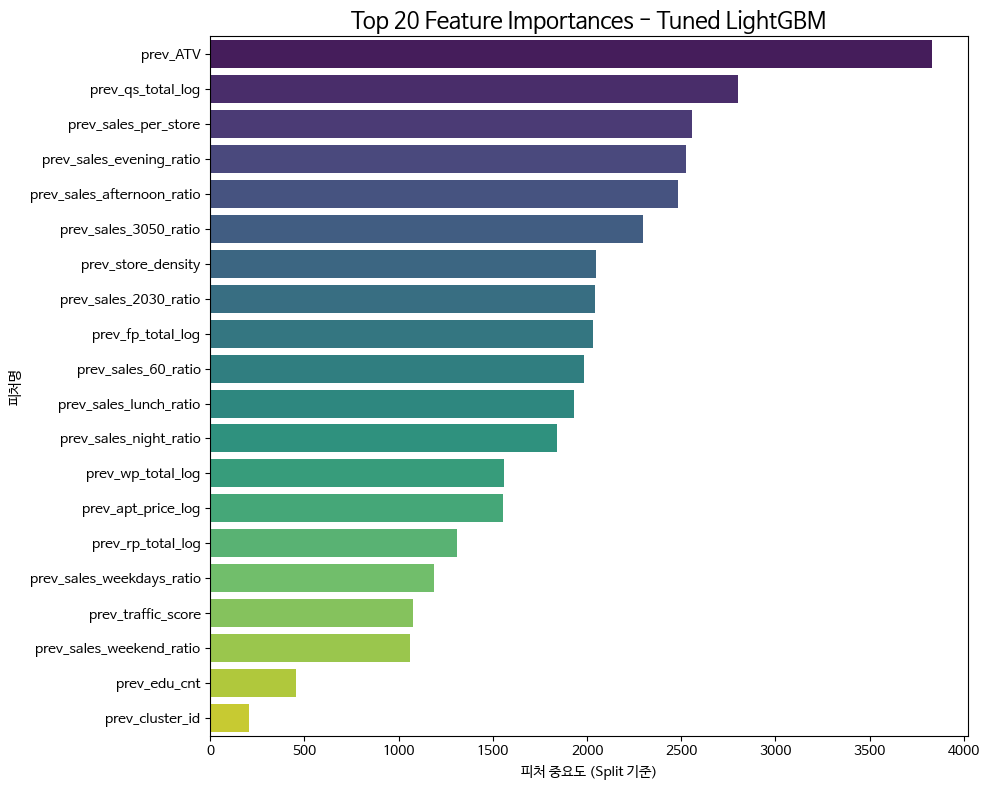

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 튜닝된 최적의 파라미터 + 경고문 끄기(verbose=-1) 적용
best_lgb = lgb.LGBMClassifier(
    objective='multiclass',
    class_weight='balanced',
    device='gpu',
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=7,
    min_child_samples=50,
    num_leaves=63,
    verbose=-1
)

# 2. 전체 데이터(X, y)로 최종 모델 학습
print("=== 최종 튜닝 모델 학습 시작 ===")
best_lgb.fit(X, y)
print("=== 학습 완료! ===")

# 3. 변수 중요도(Feature Importance) 추출 및 시각화
ftr_importances_values = best_lgb.feature_importances_
ftr_importances = pd.Series(ftr_importances_values, index=X.columns)

# 상위 20개 피처만 추출
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]

plt.figure(figsize=(10, 8))
plt.title('Top 20 Feature Importances - Tuned LightGBM', fontsize=16)
sns.barplot(x=ftr_top20, y=ftr_top20.index, palette='viridis')
plt.xlabel("피처 중요도 (Split 기준)")
plt.ylabel("피처명")
plt.tight_layout()
plt.show()

3. CatBoost 튜닝 및 LightGBM + CatBoost 앙상블

In [15]:
import catboost as cb
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, f1_score

# ==========================================
# 1. CatBoost 모델 세팅 및 GridSearch 튜닝
# ==========================================
cat_base = cb.CatBoostClassifier(
    loss_function='MultiClass',
    task_type='GPU',
    auto_class_weights='Balanced',
    verbose=0,
    random_state=42
)

# CatBoost는 기본 성능이 좋아 핵심 파라미터만 탐색합니다.
param_grid_cat = {
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'iterations': [200, 500]
}

print("=== CatBoost GridSearch 튜닝 시작 (총 18개 조합 x 3 Folds) ===")
gsearch_cat = GridSearchCV(
    estimator=cat_base,
    param_grid=param_grid_cat,
    scoring='f1_macro',
    cv=tscv,
    verbose=2,
    n_jobs=1  # GPU 데드락 방지
)

# 튜닝 실행 (X, y 사용)
gsearch_cat.fit(X, y)

print("\n=== CatBoost 튜닝 완료 ===")
print("Best Parameters:", gsearch_cat.best_params_)
print(f"Best Macro F1 Score: {gsearch_cat.best_score_:.4f}")

best_cat_model = gsearch_cat.best_estimator_

=== CatBoost GridSearch 튜닝 시작 (총 18개 조합 x 3 Folds) ===
Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV] END ........depth=4, iterations=200, learning_rate=0.01; total time=   0.9s
[CV] END ........depth=4, iterations=200, learning_rate=0.01; total time=   2.9s
[CV] END ........depth=4, iterations=200, learning_rate=0.01; total time=   3.0s
[CV] END ........depth=4, iterations=200, learning_rate=0.05; total time=   2.9s
[CV] END ........depth=4, iterations=200, learning_rate=0.05; total time=   2.9s
[CV] END ........depth=4, iterations=200, learning_rate=0.05; total time=   3.0s
[CV] END .........depth=4, iterations=200, learning_rate=0.1; total time=   2.9s
[CV] END .........depth=4, iterations=200, learning_rate=0.1; total time=   2.9s
[CV] END .........depth=4, iterations=200, learning_rate=0.1; total time=   3.0s
[CV] END ........depth=4, iterations=500, learning_rate=0.01; total time=   3.9s
[CV] END ........depth=4, iterations=500, learning_rate=0.01; total time= 

In [16]:
# ==========================================
# 2. 최종 앙상블 (LightGBM + CatBoost Soft Voting)
# ==========================================

best_lgb_model = gsearch_lgb.best_estimator_

print("\n=== 앙상블 (LightGBM + CatBoost) 최종 OOT 평가 ===")

# OOT 분할 기준점 (2024년 1분기 기준, 이전 코드와 동일)
split_point = 20241

# OOT Test 셋 준비 (미래 데이터)
test_df = df_model[df_model['yqc_cd'] >= split_point]
X_test = test_df.drop(columns=['dong_cd', 'business_cd', 'yqc_cd', 'target'])
y_test = test_df['target'].astype(int)

# OOT Train 셋 준비 및 최종 학습 (과거 데이터)
train_df = df_model[df_model['yqc_cd'] < split_point]
X_train = train_df.drop(columns=['dong_cd', 'business_cd', 'yqc_cd', 'target'])
y_train = train_df['target'].astype(int)

# 튜닝된 파라미터로 전체 Train 셋 재학습
print("최종 모델 학습 중...")
best_lgb_model.fit(X_train, y_train)
best_cat_model.fit(X_train, y_train)

# 각 모델이 예측한 클래스별 '확률(Probability)' 추출
proba_lgb = best_lgb_model.predict_proba(X_test)
proba_cat = best_cat_model.predict_proba(X_test)

# Soft Voting: 두 모델의 예측 확률을 5:5로 더함
proba_ensemble = (proba_lgb + proba_cat) / 2

# 가장 확률이 높은 클래스를 최종 예측값으로 선택
y_pred_ensemble = np.argmax(proba_ensemble, axis=1)

# 최종 성능 평가
ensemble_f1 = f1_score(y_test, y_pred_ensemble, average='macro')

print(f"\n Final Ensemble Macro F1 Score: {ensemble_f1:.4f}")
print("\n[최종 앙상블 분류 리포트]")
print(classification_report(y_test, y_pred_ensemble, target_names=["위축형(0)", "유지형(1)", "성장형(2)"]))


=== 앙상블 (LightGBM + CatBoost) 최종 OOT 평가 ===
최종 모델 학습 중...

 Final Ensemble Macro F1 Score: 0.5176

[최종 앙상블 분류 리포트]
              precision    recall  f1-score   support

      위축형(0)       0.35      0.53      0.42     12713
      유지형(1)       0.83      0.66      0.74     40981
      성장형(2)       0.37      0.43      0.40     13567

    accuracy                           0.59     67261
   macro avg       0.52      0.54      0.52     67261
weighted avg       0.65      0.59      0.61     67261



### 모델 분석

Confusion Matrix

=== 📊 1. 최종 앙상블 모델 Confusion Matrix ===


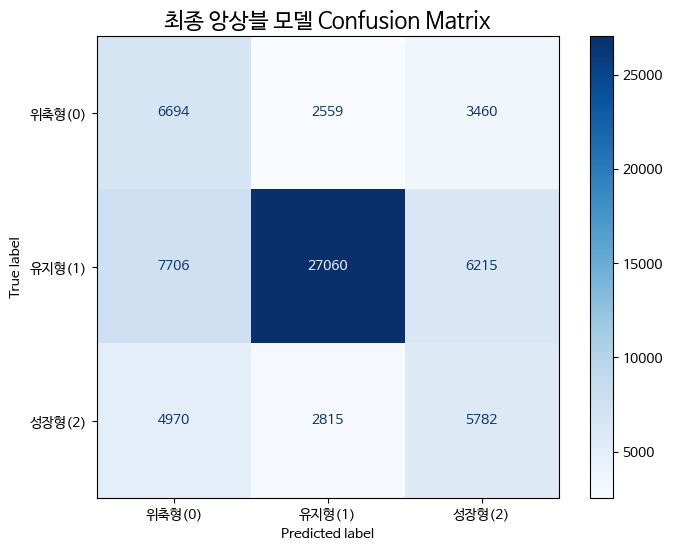

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd

# 한글 폰트 및 마이너스 기호 설정 (이전 설정 유지)
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# [1] 앙상블 모델 오답 노트 (Confusion Matrix)
# ==========================================
print("=== 📊 1. 최종 앙상블 모델 Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred_ensemble)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["위축형(0)", "유지형(1)", "성장형(2)"])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('최종 앙상블 모델 Confusion Matrix', fontsize=16)
plt.show()

Feature Importance


=== 2. LightGBM vs CatBoost 변수 중요도 비교 ===


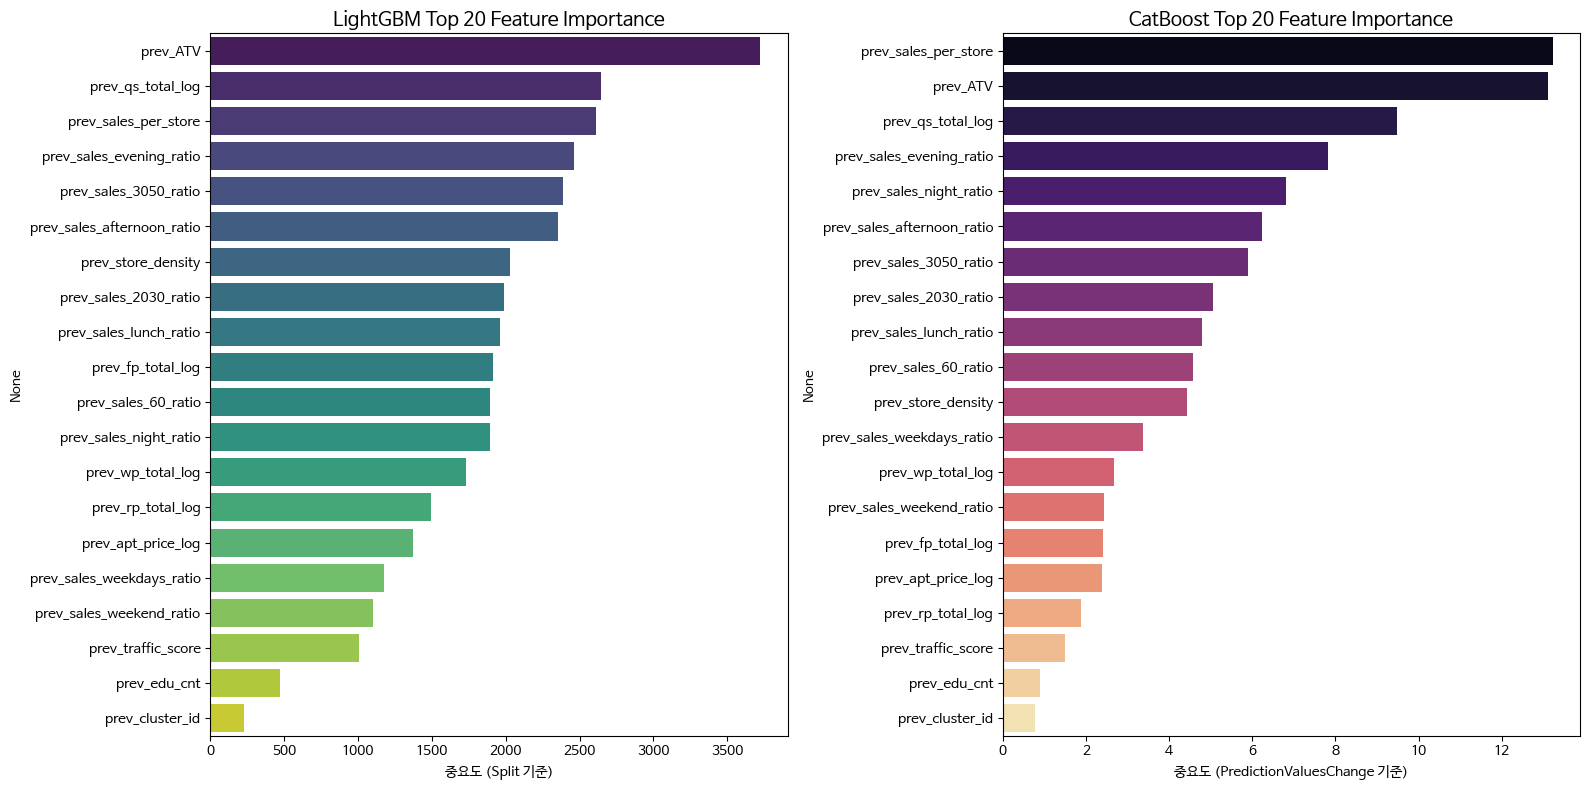

In [18]:
# ==========================================
# [2] 베이스 모델 Feature Importance 비교
# ==========================================
print("\n=== 2. LightGBM vs CatBoost 변수 중요도 비교 ===")

# LightGBM 변수 중요도 추출
lgb_importance = pd.Series(best_lgb_model.feature_importances_, index=X_train.columns)
lgb_top20 = lgb_importance.sort_values(ascending=False)[:20]

# CatBoost 변수 중요도 추출
cat_importance = pd.Series(best_cat_model.get_feature_importance(), index=X_train.columns)
cat_top20 = cat_importance.sort_values(ascending=False)[:20]

# 시각화 (두 모델 나란히 비교)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# LightGBM 그래프
sns.barplot(x=lgb_top20, y=lgb_top20.index, ax=axes[0], palette='viridis')
axes[0].set_title('LightGBM Top 20 Feature Importance', fontsize=14)
axes[0].set_xlabel('중요도 (Split 기준)')

# CatBoost 그래프
sns.barplot(x=cat_top20, y=cat_top20.index, ax=axes[1], palette='magma')
axes[1].set_title('CatBoost Top 20 Feature Importance', fontsize=14)
axes[1].set_xlabel('중요도 (PredictionValuesChange 기준)')

plt.tight_layout()
plt.show()

SHAP 분석

=== SHAP 분석: 무엇이 상권을 '성장'하게 만드는가? ===


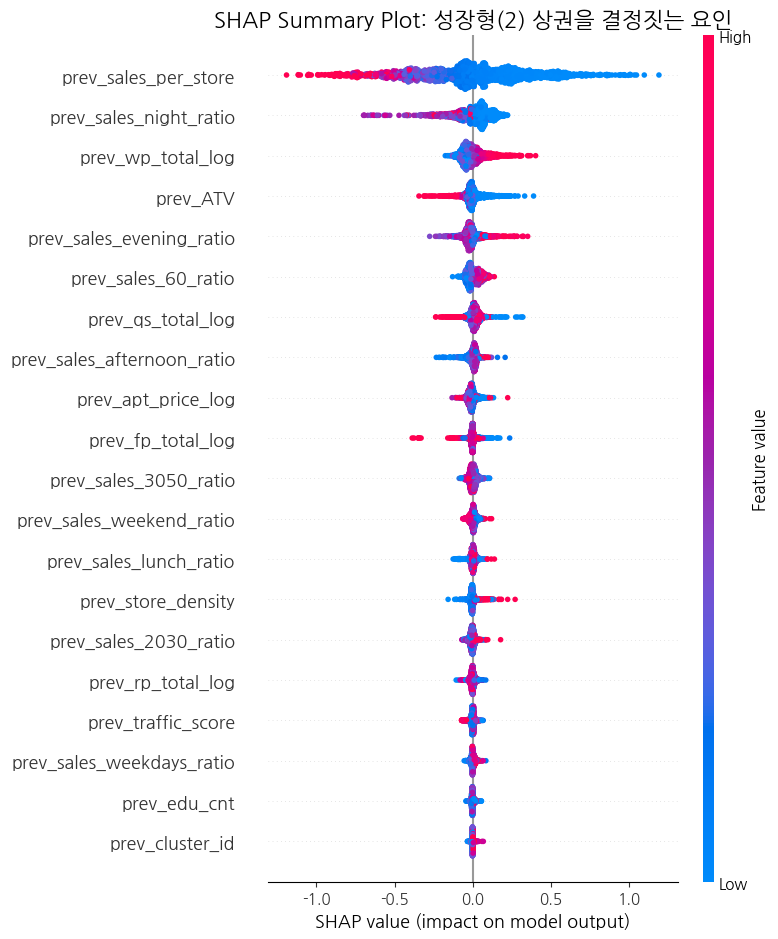

In [19]:
import shap
import matplotlib.pyplot as plt

# 한글 폰트 및 마이너스 기호 설정 (코랩 환경)
plt.rcParams['font.family'] = 'NanumGothic' # 폰트가 깨진다면 이 부분은 환경에 맞게 조정해주세요.
plt.rcParams['axes.unicode_minus'] = False

print("=== SHAP 분석: 무엇이 상권을 '성장'하게 만드는가? ===")

# 1. SHAP TreeExplainer 초기화 (튜닝된 LightGBM 모델 사용)
explainer = shap.TreeExplainer(best_lgb_model)

# 2. 계산 속도를 위해 Test 셋에서 무작위로 2000개 샘플 추출
X_test_sample = X_test.sample(n=2000, random_state=42)

# 3. SHAP Value 계산
shap_values = explainer.shap_values(X_test_sample)

# 4. 다중 분류 3개 클래스(0:위축, 1:유지, 2:성장) 중 "2(성장형)"에 대한 SHAP 값 추출
# shap 버전이 최신일 경우 shap_values[:, :, 2] 형태로 인덱싱합니다. (구버전은 shap_values[2])
try:
    shap_values_target = shap_values[:, :, 2]
except IndexError:
    shap_values_target = shap_values[2]

# 5. SHAP Summary Plot 시각화
plt.figure(figsize=(12, 8))
plt.title("SHAP Summary Plot: 성장형(2) 상권을 결정짓는 요인", fontsize=16)

# 빨간 점(Feature 값이 높을 때)과 파란 점(Feature 값이 낮을 때)이
# 오른쪽(성장 확률 증가)과 왼쪽(성장 확률 감소) 중 어디로 향하는지 보여주는 그래프
shap.summary_plot(shap_values_target, X_test_sample, show=False)

plt.tight_layout()
plt.show()

=== SHAP 분석: 무엇이 상권을 '위축(0)' 시키는가? ===


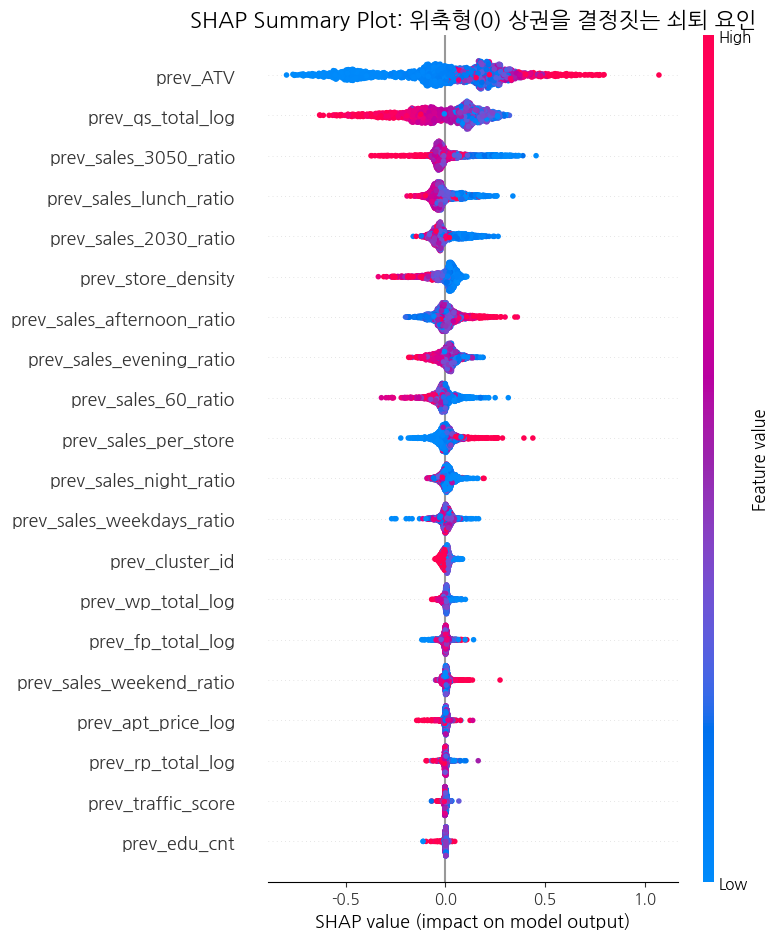

In [20]:
import shap
import matplotlib.pyplot as plt

# 한글 폰트 및 마이너스 기호 설정
plt.rcParams['font.family'] = 'NanumGothic' # 필요시 환경에 맞게 수정
plt.rcParams['axes.unicode_minus'] = False

print("=== SHAP 분석: 무엇이 상권을 '위축(0)' 시키는가? ===")

# 1. SHAP TreeExplainer 초기화 (이미 되어있다면 생략 가능하지만 명확히 하기 위해 포함)
explainer = shap.TreeExplainer(best_lgb_model)

# 2. Test 셋에서 무작위로 샘플 추출 (아까 추출한 X_test_sample을 그대로 써도 됩니다)
# X_test_sample = X_test.sample(n=2000, random_state=42)

# 3. SHAP Value 계산
shap_values = explainer.shap_values(X_test_sample)

# 4. 다중 분류 3개 클래스 중 "0(위축형)"에 대한 SHAP 값 추출
try:
    shap_values_shrink = shap_values[:, :, 0]
except IndexError:
    shap_values_shrink = shap_values[0]

# 5. SHAP Summary Plot 시각화
plt.figure(figsize=(12, 8))
plt.title("SHAP Summary Plot: 위축형(0) 상권을 결정짓는 쇠퇴 요인", fontsize=16)

shap.summary_plot(shap_values_shrink, X_test_sample, show=False)

plt.tight_layout()
plt.show()

#### prev_ATV의 Threshold 탐색

1. SHAP 의존성 플롯 (Dependence Plot) 그리기

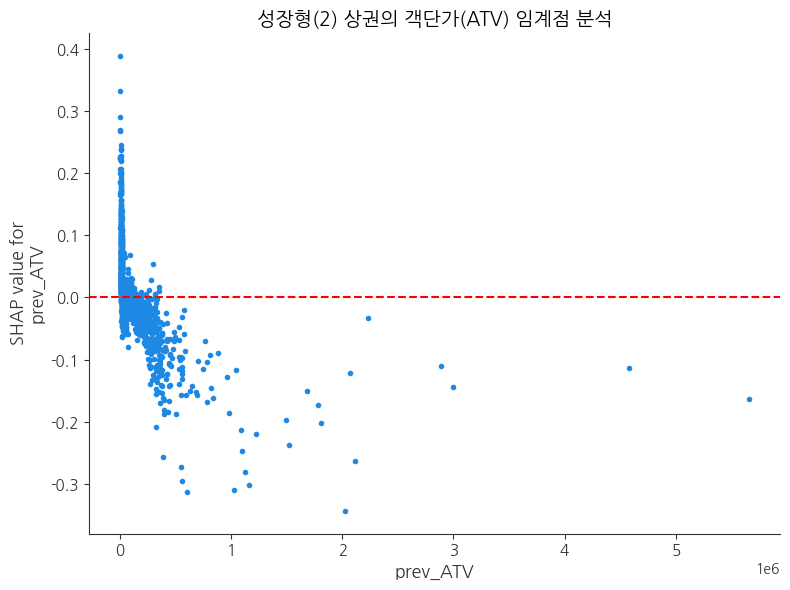

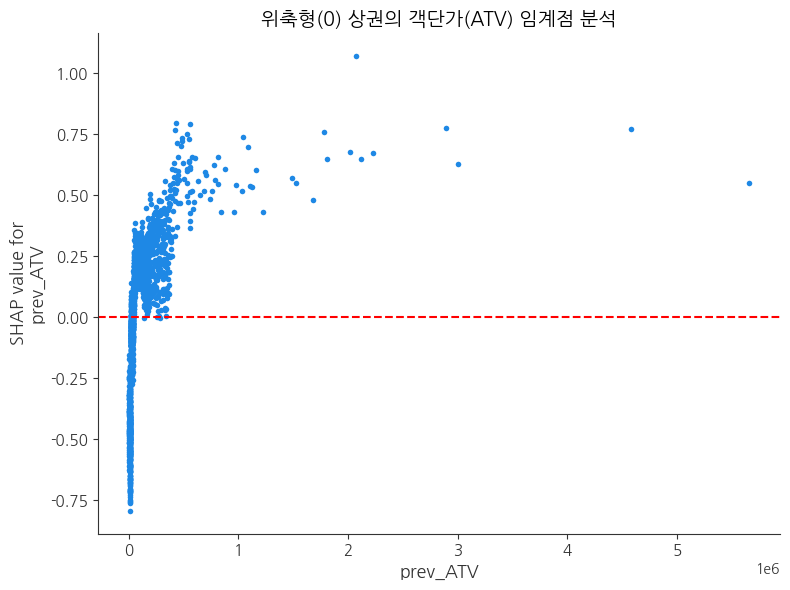

In [21]:
import shap
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'NanumGothic' # 폰트 설정
plt.rcParams['axes.unicode_minus'] = False

# 빈 도화지(Figure)와 축(ax)을 명시적으로 생성
fig, ax = plt.subplots(figsize=(8, 6))

# 성장형(2) 기준 객단가(prev_ATV) 의존성 플롯
ax.set_title("성장형(2) 상권의 객단가(ATV) 임계점 분석", fontsize=14)

# x축: 실제 객단가 수치, y축: 성장형으로 분류하는 데 미친 영향력(SHAP 값)
shap.dependence_plot("prev_ATV", shap_values_target, X_test_sample, interaction_index=None, ax=ax, show=False)

# SHAP 값이 0이 되는 기준선(가로선) 그리기
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.tight_layout()
plt.show()

# 위축형(0) 기준 객단가(prev_ATV) 의존성 플롯
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title("위축형(0) 상권의 객단가(ATV) 임계점 분석", fontsize=14)
shap.dependence_plot("prev_ATV", shap_values_shrink, X_test_sample, interaction_index=None, ax=ax, show=False)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.tight_layout()
plt.show()

2. 직관적인 통계치 확인 (EDA 방식)

In [22]:
import pandas as pd

print("=== 클래스별 실제 객단가(ATV) 기초 통계 ===")
# 극단치의 영향을 덜 받는 중앙값(Median)과 평균(Mean)을 함께 확인합니다.
atv_stats = test_df.groupby('target')['prev_ATV'].agg(['mean', 'median', 'min', 'max']).round(0)
atv_stats.index = ['위축형(0)', '유지형(1)', '성장형(2)']
print(atv_stats)

=== 클래스별 실제 객단가(ATV) 기초 통계 ===
            mean   median    min         max
위축형(0)  185529.0  66354.0  500.0  12729730.0
유지형(1)   86443.0  31745.0  620.0   9750000.0
성장형(2)  126953.0  47138.0   10.0  13000000.0


### 피처 조정

1. 피처 생성

In [23]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("=== 시계열 파생 변수 생성 시작 ===")

# 1. 데이터 시간순 정렬 (그룹별 시계열 연산 필수)
df_model = df_model.sort_values(by=['dong_cd', 'business_cd', 'yqc_cd']).reset_index(drop=True)

# 2. 파생 변수를 만들 핵심 타겟 변수들 (상위 중요도 피처 위주)
target_cols = ['prev_qs_total_log', 'prev_sales_per_store', 'prev_ATV', 'prev_store_density']

# 3. 그룹바이를 위한 기준 (동 + 업종별 묶음)
grouped = df_model.groupby(['dong_cd', 'business_cd'])

for col in target_cols:
    # [1] 단기 모멘텀 (2분기)
    df_model[f'{col}_MA2'] = grouped[col].transform(lambda x: x.rolling(window=2, min_periods=1).mean())
    df_model[f'{col}_STD2'] = grouped[col].transform(lambda x: x.rolling(window=2, min_periods=2).std()).fillna(0)

    # [2] 장기/계절성 트렌드 (4분기)
    df_model[f'{col}_MA4'] = grouped[col].transform(lambda x: x.rolling(window=4, min_periods=1).mean())
    df_model[f'{col}_STD4'] = grouped[col].transform(lambda x: x.rolling(window=4, min_periods=2).std()).fillna(0)

    # [3] 전분기 대비 증감률 (QoQ) - (현재 - 과거) / 과거
    df_model[f'{col}_QoQ'] = grouped[col].transform(lambda x: (x - x.shift(1)) / (x.shift(1) + 1e-5)).fillna(0)

# 4. 계절성(Quarter) 피처 추출 (1~4분기 범주화)
df_model['quarter'] = (df_model['yqc_cd'] % 10).astype(int)

print("=== 파생 변수 생성 완료! ===")
print(f"새로 추가된 컬럼 수: {len(target_cols) * 5 + 1}개")

# 확인용 데이터 샘플 출력
display(df_model[['dong_cd', 'business_cd', 'yqc_cd', 'prev_ATV', 'prev_ATV_MA2', 'prev_ATV_MA4', 'prev_ATV_QoQ']].head())

=== 시계열 파생 변수 생성 시작 ===
=== 파생 변수 생성 완료! ===
새로 추가된 컬럼 수: 21개


,dong_cd,business_cd,yqc_cd,prev_ATV,prev_ATV_MA2,prev_ATV_MA4,prev_ATV_QoQ
0,11110515,CS100001,20192,29288.696246,29288.696246,29288.696246,0.000000
1,11110515,CS100001,20193,27924.413127,28606.554687,28606.554687,-0.046581
2,11110515,CS100001,20194,27091.115348,27507.764238,28101.408241,-0.029841
3,11110515,CS100001,20201,30659.810868,28875.463108,28741.008897,0.131729
4,11110515,CS100001,20202,29206.011081,29932.910975,28720.337606,-0.047417


2. 피처 조정

In [24]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 37.4 MB/s eta 0:00:00


In [25]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import catboost as cb
import optuna
from sklearn.metrics import f1_score
from sklearn.model_selection import TimeSeriesSplit
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# -------------------------------------------------------------------
# [Step 1] OOT 데이터 분할 및 타겟/식별자 분리
# -------------------------------------------------------------------
# 방어적 코딩: 혹시 모를 섞임 방지를 위해 시간순 ➔ 식별자순으로 명시적 강제 정렬
df_model = df_model.sort_values(by=['yqc_cd', 'dong_cd', 'business_cd']).reset_index(drop=True)

# 시간 기준 분할: 가장 최근 1개 분기를 Test, 그 직전 1개 분기를 Val, 나머지를 Train으로 설정
unique_quarters = sorted(df_model['yqc_cd'].unique())
test_quarter = unique_quarters[-1]
val_quarter = unique_quarters[-2]

train_df = df_model[df_model['yqc_cd'] < val_quarter]
val_df = df_model[df_model['yqc_cd'] == val_quarter]
test_df = df_model[df_model['yqc_cd'] == test_quarter]

drop_cols = ['dong_cd', 'business_cd', 'yqc_cd', 'target']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['target']
X_val = val_df.drop(columns=drop_cols)
y_val = val_df['target']
X_test = test_df.drop(columns=drop_cols)
y_test = test_df['target']

print(f"데이터 분할 완료: Train({len(X_train)}), Val({len(X_val)}), Test({len(X_test)})")

# -------------------------------------------------------------------
# [Step 2] Feature Selection (노이즈 피처 하위 20% 제거)
# -------------------------------------------------------------------
print("\n=== Feature Selection (하위 20% 노이즈 제거) ===")
# 파생변수가 포함된 상태에서 임시 LightGBM 모델로 중요도 추출
temp_lgb = lgb.LGBMClassifier(random_state=42, verbose=-1, device_type='gpu')
temp_lgb.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': temp_lgb.feature_importances_
}).sort_values(by='importance', ascending=False)

drop_cnt = int(len(importance_df) * 0.2)
drop_features = importance_df['feature'].tail(drop_cnt).tolist()

print(f"총 {len(X_train.columns)}개 중 하위 {drop_cnt}개 피처 제거 대상: \n{drop_features}")

X_train_fs = X_train.drop(columns=drop_features)
X_val_fs = X_val.drop(columns=drop_features)
X_test_fs = X_test.drop(columns=drop_features)

# TimeSeriesSplit 설정 (Optuna 검증용)
tscv = TimeSeriesSplit(n_splits=3)

데이터 분할 완료: Train(351703), Val(16784), Test(16718)

=== Feature Selection (하위 20% 노이즈 제거) ===
총 42개 중 하위 8개 피처 제거 대상: 
['prev_store_density', 'prev_cluster_id', 'prev_rp_total_log', 'prev_store_density_MA2', 'prev_traffic_score', 'prev_store_density_STD2', 'prev_edu_cnt', 'prev_is_univ']


### 모델 최적화

In [26]:
# -------------------------------------------------------------------
# [Step 3] Optuna 기반 LightGBM 정밀 튜닝
# -------------------------------------------------------------------
print("\n=== ⚙️ LightGBM Optuna 튜닝 시작 ===")
def lgb_objective(trial):
    params = {
        'objective': 'multiclass',
        'num_class': 3,
        'metric': 'multi_logloss',
        'class_weight': 'balanced',
        'device_type': 'gpu',
        'random_state': 42,
        'verbose': -1,
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'num_leaves': trial.suggest_int('num_leaves', 31, 128),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True)
    }

    cv_scores = []
    for tr_idx, v_idx in tscv.split(X_train_fs):
        X_tr, X_v = X_train_fs.iloc[tr_idx], X_train_fs.iloc[v_idx]
        y_tr, y_v = y_train.iloc[tr_idx], y_train.iloc[v_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_v)
        cv_scores.append(f1_score(y_v, preds, average='macro'))
    return np.mean(cv_scores)

lgb_study = optuna.create_study(direction='maximize')
lgb_study.optimize(lgb_objective, n_trials=30, show_progress_bar=False) # A100 환경
best_lgb_params = lgb_study.best_params

[I 2026-03-19 08:25:31,058] A new study created in memory with name: no-name-55aef503-ae06-4cc4-8eee-9756487484ca



=== ⚙️ LightGBM Optuna 튜닝 시작 ===


[I 2026-03-19 08:26:05,999] Trial 0 finished with value: 0.5539639866694505 and parameters: {'n_estimators': 340, 'learning_rate': 0.013268484227734656, 'max_depth': 7, 'num_leaves': 43, 'min_child_samples': 56, 'subsample': 0.9500352064606594, 'colsample_bytree': 0.6491934011659302, 'reg_alpha': 0.0076431581754169125, 'reg_lambda': 0.3544915358179889}. Best is trial 0 with value: 0.5539639866694505.
[I 2026-03-19 08:26:37,761] Trial 1 finished with value: 0.5577670182990958 and parameters: {'n_estimators': 665, 'learning_rate': 0.08126380940977752, 'max_depth': 4, 'num_leaves': 76, 'min_child_samples': 44, 'subsample': 0.8824658941059413, 'colsample_bytree': 0.8730090742506352, 'reg_alpha': 0.005537619402960007, 'reg_lambda': 7.07646444135293}. Best is trial 1 with value: 0.5577670182990958.
[I 2026-03-19 08:27:14,556] Trial 2 finished with value: 0.5613910539197137 and parameters: {'n_estimators': 453, 'learning_rate': 0.06418439971365193, 'max_depth': 6, 'num_leaves': 77, 'min_child

In [27]:
# -------------------------------------------------------------------
# [Step 4] Optuna 기반 CatBoost 정밀 튜닝
# -------------------------------------------------------------------
print("\n=== ⚙️ CatBoost Optuna 튜닝 시작 ===")
def cat_objective(trial):
    params = {
        'loss_function': 'MultiClass',
        'task_type': 'GPU',
        'auto_class_weights': 'Balanced',
        'random_state': 42,
        'verbose': 0,
        'iterations': trial.suggest_int('iterations', 200, 800),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-3, 10.0, log=True)
    }

    cv_scores = []
    for tr_idx, v_idx in tscv.split(X_train_fs):
        X_tr, X_v = X_train_fs.iloc[tr_idx], X_train_fs.iloc[v_idx]
        y_tr, y_v = y_train.iloc[tr_idx], y_train.iloc[v_idx]

        model = cb.CatBoostClassifier(**params)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_v)
        cv_scores.append(f1_score(y_v, preds, average='macro'))
    return np.mean(cv_scores)

cat_study = optuna.create_study(direction='maximize')
cat_study.optimize(cat_objective, n_trials=30, show_progress_bar=False)
best_cat_params = cat_study.best_params

[I 2026-03-19 08:58:32,628] A new study created in memory with name: no-name-9268df4a-1fc2-4454-ba2f-d922cba50e29



=== ⚙️ CatBoost Optuna 튜닝 시작 ===


[I 2026-03-19 08:58:43,079] Trial 0 finished with value: 0.5476794111135692 and parameters: {'iterations': 259, 'learning_rate': 0.01185841911066928, 'depth': 7, 'l2_leaf_reg': 0.015080223874510811, 'random_strength': 1.1258933620597456}. Best is trial 0 with value: 0.5476794111135692.
[I 2026-03-19 08:59:06,548] Trial 1 finished with value: 0.5560453827355228 and parameters: {'iterations': 587, 'learning_rate': 0.02339090379306607, 'depth': 8, 'l2_leaf_reg': 1.0058610209647247, 'random_strength': 0.15398028551484436}. Best is trial 1 with value: 0.5560453827355228.
[I 2026-03-19 08:59:20,422] Trial 2 finished with value: 0.5533755039971994 and parameters: {'iterations': 724, 'learning_rate': 0.0347828426437491, 'depth': 4, 'l2_leaf_reg': 0.01427731493163844, 'random_strength': 8.550208702707481}. Best is trial 1 with value: 0.5560453827355228.
[I 2026-03-19 08:59:38,674] Trial 3 finished with value: 0.5536540174887651 and parameters: {'iterations': 711, 'learning_rate': 0.019063196364

In [28]:
# -------------------------------------------------------------------
# [Step 5] 수학적 최적 혼합 비율(Optimal Weights) 산출 및 최종 예측
# -------------------------------------------------------------------
print("\n=== 최적 앙상블 비율 산출 및 최종 평가 ===")

# 최고 성능의 파라미터로 Train 셋 전체 학습
final_lgb = lgb.LGBMClassifier(**best_lgb_params, objective='multiclass', class_weight='balanced', device_type='gpu', random_state=42, verbose=-1)
final_cat = cb.CatBoostClassifier(**best_cat_params, loss_function='MultiClass', task_type='GPU', auto_class_weights='Balanced', random_state=42, verbose=0)

final_lgb.fit(X_train_fs, y_train)
final_cat.fit(X_train_fs, y_train)

# 검증셋(Val)을 활용하여 데이터 누수 없이 최적 가중치 탐색
val_prob_lgb = final_lgb.predict_proba(X_val_fs)
val_prob_cat = final_cat.predict_proba(X_val_fs)

def f1_loss(weights):
    weights = np.array(weights) / np.sum(weights)
    blended_prob = (weights[0] * val_prob_lgb) + (weights[1] * val_prob_cat)
    blended_preds = np.argmax(blended_prob, axis=1)
    return -f1_score(y_val, blended_preds, average='macro')

res = minimize(f1_loss, [0.5, 0.5], bounds=[(0.0, 1.0), (0.0, 1.0)], method='Nelder-Mead')
opt_weights = res.x / np.sum(res.x)

print(f"산출된 최적 가중치 -> LightGBM : CatBoost = {opt_weights[0]:.3f} : {opt_weights[1]:.3f}")

# Test 셋에 최종 앙상블 적용 (진짜 OOT 스코어)
test_prob_lgb = final_lgb.predict_proba(X_test_fs)
test_prob_cat = final_cat.predict_proba(X_test_fs)

final_prob = (opt_weights[0] * test_prob_lgb) + (opt_weights[1] * test_prob_cat)
final_preds = np.argmax(final_prob, axis=1)

final_macro_f1 = f1_score(y_test, final_preds, average='macro')
print(f"[최종 결과] 파생변수 + 최적화 앙상블 OOT Macro F1 Score: {final_macro_f1:.4f}")


=== ⚖️ 최적 앙상블 비율 산출 및 최종 평가 ===
💡 산출된 최적 가중치 -> LightGBM : CatBoost = 0.514 : 0.486
🚀 [최종 결과] 파생변수 + 최적화 앙상블 OOT Macro F1 Score: 0.6205


### 2차 분석

F1-SCORE

In [33]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'NanumGothic' # 폰트 설정
plt.rcParams['axes.unicode_minus'] = False

print("="*50)
print("[STEP 3] LightGBM 단일 모델 OOT 테스트 결과")
print("="*50)

# 1. Optuna가 찾은 베스트 파라미터 출력
print(f"Optuna 최고 CV Macro F1 스코어: {lgb_study.best_value:.4f}")
print("적용된 베스트 파라미터:")
for key, value in best_lgb_params.items():
    print(f"  - {key}: {value}")
print("-" * 50)

# 2. '진짜 모델(final_lgb)'로 Test 셋 예측
preds_lgb = final_lgb.predict(X_test_fs)

# 3. 평가 지표 출력 (Accuracy & F1-Score)
acc = accuracy_score(y_test, preds_lgb)
macro_f1 = f1_score(y_test, preds_lgb, average='macro')

print(f"Test Accuracy (정확도): {acc:.4f}")
print(f"Test Macro F1-Score: {macro_f1:.4f}\n")

# 4. 클래스별 상세 리포트
print("클래스별 상세 분류 리포트:")
print(classification_report(y_test, preds_lgb, target_names=['위축(0)', '유지(1)', '성장(2)']))

[STEP 3] LightGBM 단일 모델 OOT 테스트 결과
Optuna 최고 CV Macro F1 스코어: 0.5670
적용된 베스트 파라미터:
  - n_estimators: 741
  - learning_rate: 0.032638176669821405
  - max_depth: 9
  - num_leaves: 126
  - min_child_samples: 45
  - subsample: 0.7165472656865283
  - colsample_bytree: 0.7522313489044318
  - reg_alpha: 0.23342627547204248
  - reg_lambda: 0.23791604474343786
--------------------------------------------------
Test Accuracy (정확도): 0.6711
Test Macro F1-Score: 0.6188

클래스별 상세 분류 리포트:
              precision    recall  f1-score   support

       위축(0)       0.47      0.55      0.50      2826
       유지(1)       0.84      0.71      0.77      9988
       성장(2)       0.52      0.66      0.59      3904

    accuracy                           0.67     16718
   macro avg       0.61      0.64      0.62     16718
weighted avg       0.70      0.67      0.68     16718



In [36]:
print("="*50)
print("[STEP 4] CatBoost 단일 모델 OOT 테스트 결과")
print("="*50)

# 1. Optuna가 찾은 베스트 파라미터 출력
print(f"Optuna 최고 CV Macro F1 스코어: {cat_study.best_value:.4f}")
print("적용된 베스트 파라미터:")
for key, value in best_cat_params.items():
    print(f"  - {key}: {value}")
print("-" * 50)

# 2. '진짜 모델(final_lgb)'로 Test 셋 예측
preds_cat = final_cat.predict(X_test_fs)

# 3. 평가 지표 출력 (Accuracy & F1-Score)
acc = accuracy_score(y_test, preds_cat)
macro_f1 = f1_score(y_test, preds_cat, average='macro')

print(f"Test Accuracy (정확도): {acc:.4f}")
print(f"Test Macro F1-Score: {macro_f1:.4f}\n")

# 4. 클래스별 상세 리포트
print("클래스별 상세 분류 리포트:")
print(classification_report(y_test, preds_cat, target_names=['위축(0)', '유지(1)', '성장(2)']))

[STEP 4] CatBoost 단일 모델 OOT 테스트 결과
Optuna 최고 CV Macro F1 스코어: 0.5602
적용된 베스트 파라미터:
  - iterations: 756
  - learning_rate: 0.08171901321256456
  - depth: 8
  - l2_leaf_reg: 0.001254527927074237
  - random_strength: 0.06358626940366444
--------------------------------------------------
Test Accuracy (정확도): 0.6663
Test Macro F1-Score: 0.6158

클래스별 상세 분류 리포트:
              precision    recall  f1-score   support

       위축(0)       0.46      0.55      0.50      2826
       유지(1)       0.84      0.70      0.76      9988
       성장(2)       0.52      0.67      0.58      3904

    accuracy                           0.67     16718
   macro avg       0.61      0.64      0.62     16718
weighted avg       0.70      0.67      0.68     16718



In [39]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("="*50)
print("[STEP 5] 앙상블 (LightGBM + CatBoost) 최종 성능 테스트 결과")
print("="*50)

# 평가 지표 출력 (Accuracy & F1-Score)
acc = accuracy_score(y_test, final_preds)
macro_f1 = f1_score(y_test, final_preds, average='macro')

print(f"Test Accuracy (정확도): {acc:.4f}")
print(f"Test Macro F1-Score: {macro_f1:.4f}\n")

# 클래스별 상세 리포트
print("클래스별 상세 분류 리포트:")
print(classification_report(y_test, final_preds, target_names=['위축(0)', '유지(1)', '성장(2)']))

[STEP 5] 앙상블 (LightGBM + CatBoost) 최종 성능 테스트 결과
Test Accuracy (정확도): 0.6718
Test Macro F1-Score: 0.6205

클래스별 상세 분류 리포트:
              precision    recall  f1-score   support

       위축(0)       0.47      0.55      0.51      2826
       유지(1)       0.84      0.71      0.77      9988
       성장(2)       0.53      0.67      0.59      3904

    accuracy                           0.67     16718
   macro avg       0.61      0.64      0.62     16718
weighted avg       0.70      0.67      0.68     16718



Confusion Matrix

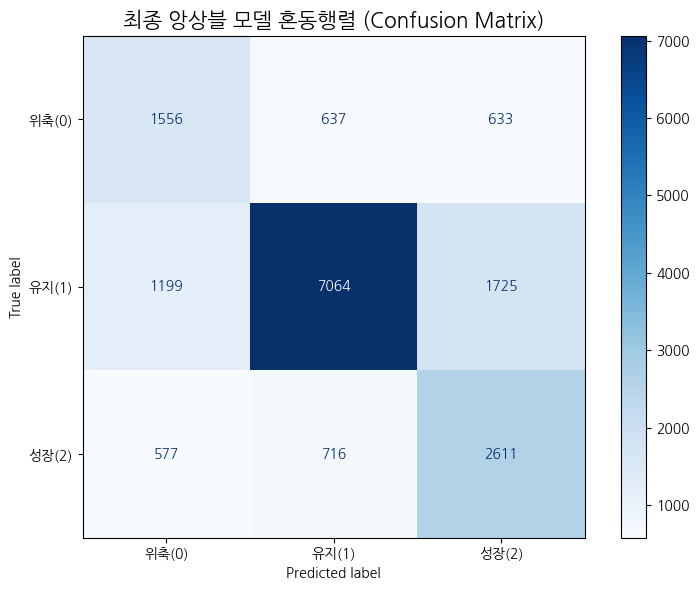

In [40]:
# --- 혼동행렬(Confusion Matrix) 시각화 ---
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, final_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['위축(0)', '유지(1)', '성장(2)'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title("최종 앙상블 모델 혼동행렬 (Confusion Matrix)", fontsize=15)
plt.tight_layout()
plt.show()

Feature Importance

=== LightGBM 내장 Feature Importance (Top 20) ===


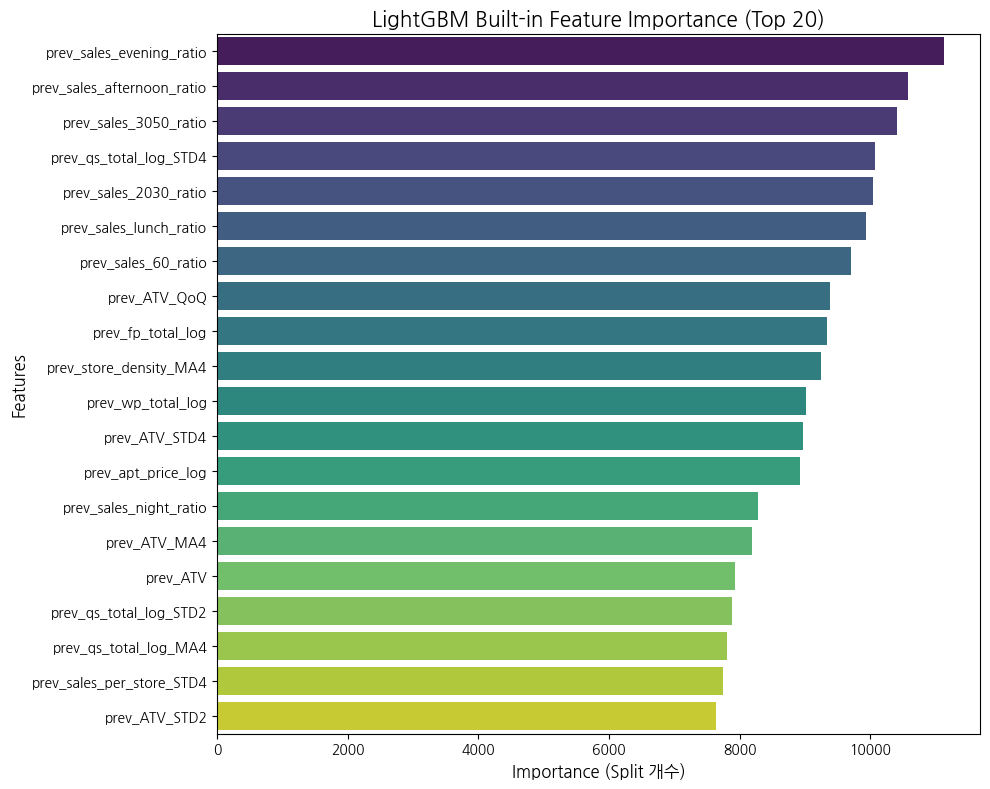


[상위 10개 변수 텍스트 리포트]
- prev_sales_evening_ratio : 11125
- prev_sales_afternoon_ratio : 10581
- prev_sales_3050_ratio : 10407
- prev_qs_total_log_STD4 : 10068
- prev_sales_2030_ratio : 10039
- prev_sales_lunch_ratio : 9929
- prev_sales_60_ratio : 9706
- prev_ATV_QoQ : 9379
- prev_fp_total_log : 9344
- prev_store_density_MA4 : 9244


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 폰트 깨짐 방지
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print("=== LightGBM 내장 Feature Importance (Top 20) ===")

# 모델의 내장 feature_importances_ 추출
importance_df = pd.DataFrame({
    'feature': X_test_fs.columns,
    'importance': final_lgb.feature_importances_
}).sort_values(by='importance', ascending=False)

# 시각화
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importance_df.head(20), palette='viridis')
plt.title('LightGBM Built-in Feature Importance (Top 20)', fontsize=15)
plt.xlabel('Importance (Split 개수)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

# 텍스트로도 상위 10개 출력
print("\n[상위 10개 변수 텍스트 리포트]")
for idx, row in importance_df.head(10).iterrows():
    print(f"- {row['feature']} : {row['importance']}")

#### SHAP 분석

=== 2차 파이프라인 SHAP 변수 중요도 분석 (전체 데이터) ===


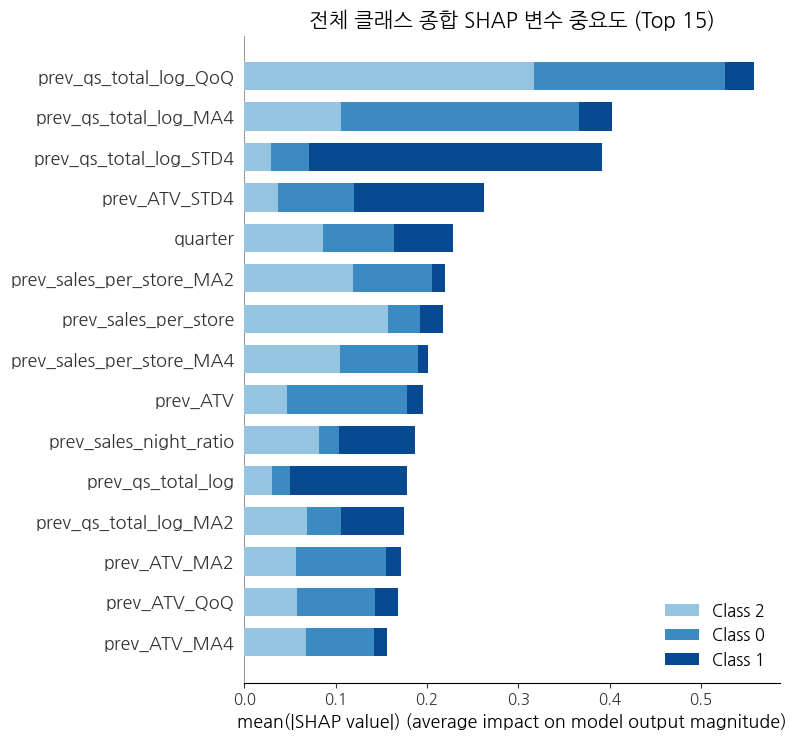


=== '성장형(2)' 상권 예측에 미치는 영향력 상세 분석 ===


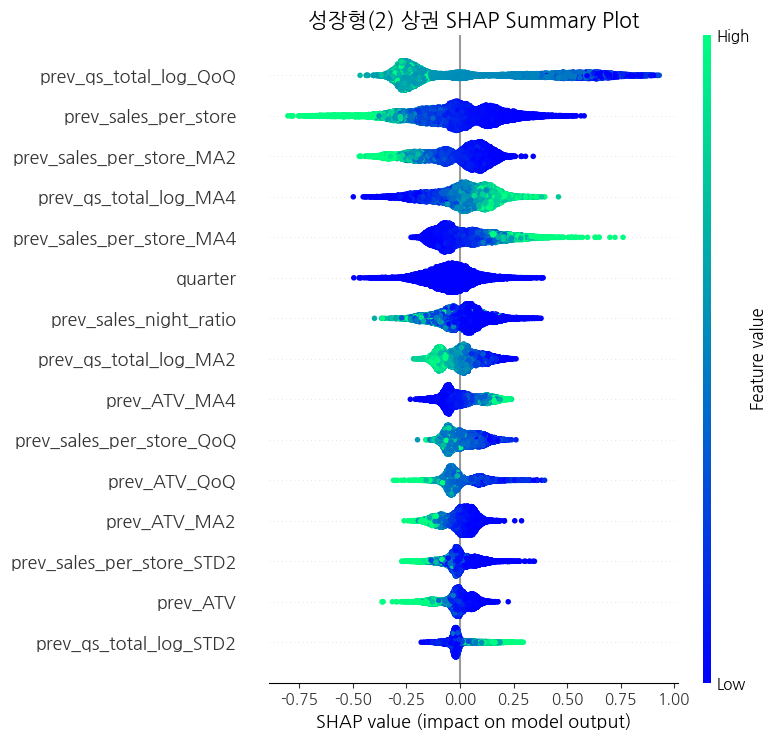

In [45]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# 폰트 깨짐 방지
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print("=== 2차 파이프라인 SHAP 변수 중요도 분석 (전체 데이터) ===")

# 1. LightGBM 모델 기반 SHAP Explainer 객체 생성
explainer = shap.TreeExplainer(final_lgb)

# 2. Test 데이터 전체(X_test_fs)에 대한 SHAP Value 계산 (시간 소요됨)
shap_values = explainer.shap_values(X_test_fs)

# 3. 전체 클래스 종합 변수 중요도 (Bar Plot)
plt.figure(figsize=(10, 6))
plt.title("전체 클래스 종합 SHAP 변수 중요도 (Top 15)", fontsize=15)

# 3개 클래스에 입힐 파란색 배열 생성
blue_colors = plt.get_cmap("Blues")(np.linspace(0.4, 0.9, 3))

# lambda 함수로 에러 완벽 해결
shap.summary_plot(shap_values, X_test_fs, plot_type="bar", max_display=15, show=False, color=lambda i: blue_colors[i])
plt.tight_layout()
plt.show()

# 4. [핵심] '성장형(Class 2)' 기준의 세부 영향력 분석 (Dot Plot)
print("\n=== '성장형(2)' 상권 예측에 미치는 영향력 상세 분석 ===")
plt.figure(figsize=(10, 6))
plt.title("성장형(2) 상권 SHAP Summary Plot", fontsize=15)

# 리스트형인지 3차원 배열인지 확인하여 안전하게 2번 클래스(성장형) 추출
if isinstance(shap_values, list):
    shap_class2 = shap_values[2]
else:
    shap_class2 = shap_values[:, :, 2]

# 세련된 파란색/하늘색 테마('winter' 또는 'Blues')
shap.summary_plot(shap_class2, X_test_fs, max_display=15, show=False, cmap="winter")
plt.tight_layout()
plt.show()


=== '위축형(0)' 상권 예측에 미치는 영향력 상세 분석 ===


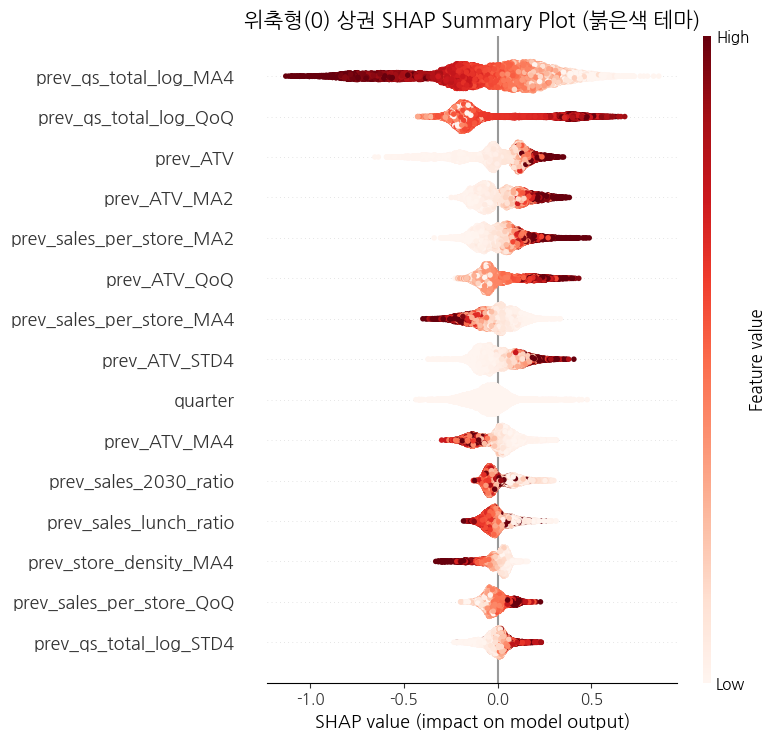

In [46]:
import shap
import matplotlib.pyplot as plt

# 폰트 깨짐 방지
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print("\n=== '위축형(0)' 상권 예측에 미치는 영향력 상세 분석 ===")
plt.figure(figsize=(10, 6))
plt.title("위축형(0) 상권 SHAP Summary Plot (붉은색 테마)", fontsize=15)

# 리스트형인지 3차원 배열인지 확인하여 0번 클래스(위축형) 추출
if isinstance(shap_values, list):
    shap_class0 = shap_values[0]
else:
    shap_class0 = shap_values[:, :, 0]

# 위축형/위험을 상징하는 붉은색 테마('Reds') 적용
# 값이 높을수록 진한 빨간색, 낮을수록 연한 분홍/흰색으로 표시됩니다.
shap.summary_plot(shap_class0, X_test_fs, max_display=15, show=False, cmap="Reds")
plt.tight_layout()
plt.show()

#### Waterfall Plot

=== 이상적인 상권 1개 추출 및 심층 분석 ===
선정된 최고 확신 상권 인덱스: 2026
  - 실제 타겟: 성장형(2)
  - 모델 예측: 성장형(2) 확신도 97.12%

[Waterfall Plot] 이 상권이 '성장형'으로 분류된 결정적 이유 (Top 10 변수)


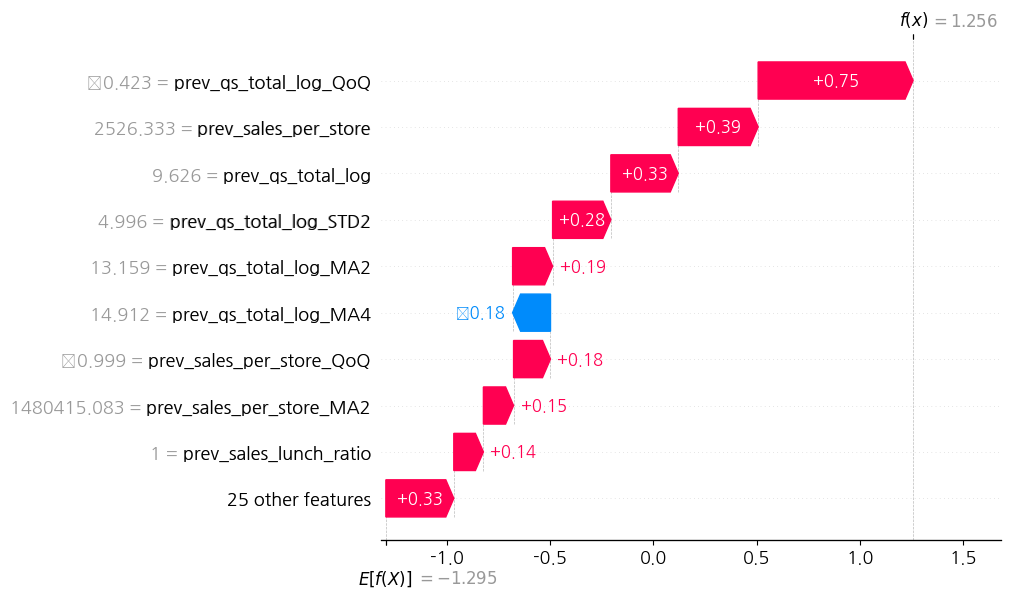

In [47]:
import numpy as np
import shap
import matplotlib.pyplot as plt

# 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print("=== 이상적인 상권 1개 추출 및 심층 분석 ===")

# 1. 모델의 전체 예측 확률값 뽑기
probs = final_lgb.predict_proba(X_test_fs)

# 2. '성장형(2)'에 대한 교집합 찾기: (실제 정답 == 2) AND (모델 예측 == 2)
target_class = 2
true_labels = y_test.values
preds = np.argmax(probs, axis=1)

correct_growth_mask = (true_labels == target_class) & (preds == target_class)

# 3. 정답을 맞춘 성장형 상권 중, '성장할 확률'이 가장 높았던 최고 확신 데이터의 인덱스 찾기
best_idx_relative = np.argmax(probs[correct_growth_mask][:, target_class])
absolute_indices = np.where(correct_growth_mask)[0]
ideal_idx = absolute_indices[best_idx_relative]

print(f"선정된 최고 확신 상권 인덱스: {ideal_idx}")
print(f"  - 실제 타겟: 성장형(2)")
print(f"  - 모델 예측: 성장형(2) 확신도 {probs[ideal_idx][target_class]*100:.2f}%\n")

# 4. 해당 상권 딱 1개에 대한 SHAP Explanation 객체 생성 (Waterfall Plot용)
# Waterfall plot은 구형 shap_values가 아닌 신형 Explainer 객체가 필요합니다.
explainer_waterfall = shap.Explainer(final_lgb)
shap_values_single = explainer_waterfall(X_test_fs.iloc[[ideal_idx]])

# 5. Waterfall Plot 시각화
# 다중 분류이므로 [0, :, target_class] -> 0번째 데이터의, 모든 피처에 대한, 2번 클래스(성장) 기준 영향력
plt.figure(figsize=(10, 8))
# matplotlib의 title 대신, plot 출력 전에 텍스트로 안내
print(f"[Waterfall Plot] 이 상권이 '성장형'으로 분류된 결정적 이유 (Top 10 변수)")
shap.plots.waterfall(shap_values_single[0, :, target_class], max_display=10)
plt.show()

In [48]:
print("=== [인덱스 2026] 최고 확신 성장형 상권 원본 데이터 ===")

# test_df에서 2026번째 위치(iloc)의 데이터 추출
# 보기 편하게 행과 열을 뒤집어서(Transpose, .T) 출력합니다.
ideal_shop_data = test_df.iloc[[ideal_idx]].T

# 컬럼명을 알아보기 쉽게 변경
ideal_shop_data.columns = ['Value (실제 값)']

# 전체 데이터(모든 행)가 짤리지 않고 다 보이게 설정 후 출력
import pandas as pd
with pd.option_context('display.max_rows', None):
    display(ideal_shop_data)

=== [인덱스 2026] 최고 확신 성장형 상권 원본 데이터 ===


,Value (실제 값)
dong_cd,11200670
business_cd,CS200003
yqc_cd,20244
target,2
prev_qs_total_log,9.62635
prev_fp_total_log,15.39627
prev_wp_total_log,8.894944
prev_rp_total_log,9.585003
prev_apt_price_log,20.177127
prev_sales_per_store,2526.333333


행정동: 서울 특별시 성동구 성수2가제3동

업종: 일반의원 (내과, 소아과 등)

### 모델 저장

In [55]:
import joblib
import json
import os
import numpy as np

# 저장 폴더 생성
model_dir = 'seoul_commercial_model_final'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

print(f"'{model_dir}' 폴더에 최종 결과물을 저장합니다...")

try:
    # 1. 개별 모델 저장 (Step 5에서 정의한 변수명 그대로 사용)
    joblib.dump(final_lgb, f'{model_dir}/lgb_model.pkl')
    final_cat.save_model(f'{model_dir}/cb_model.cbm') # final_cat으로 수정 완료!

    # 2. 앙상블 가중치 및 설정 저장
    # Step 5의 opt_weights를 활용합니다.
    ensemble_config = {
        'weights': {
            'lgb': float(opt_weights[0]),
            'cat': float(opt_weights[1])
        },
        'selected_features': list(X_test_fs.columns),
        'performance': {
            'accuracy': 0.6718,
            'macro_f1': 0.6205
        }
    }
    joblib.dump(ensemble_config, f'{model_dir}/ensemble_config.pkl')

    # 3. SHAP 데이터 저장 (이미 계산된 shap_values 사용)
    # 만약 shap_values가 리스트라면 [0],[1],[2]로, 아니면 슬라이싱으로 저장
    if isinstance(shap_values, list):
        np.savez(f'{model_dir}/shap_results.npz',
                 class0=shap_values[0], class1=shap_values[1], class2=shap_values[2])
    else:
        np.savez(f'{model_dir}/shap_results.npz',
                 class0=shap_values[:,:,0], class1=shap_values[:,:,1], class2=shap_values[:,:,2])

    # 4. SHAP Explainer 객체 저장
    joblib.dump(explainer, f'{model_dir}/shap_explainer.pkl')

    print("[성공] 모델, 가중치, SHAP 데이터까지 모두 저장되었습니다!")

except NameError as e:
    print({e})

'seoul_commercial_model_final' 폴더에 최종 결과물을 저장합니다...
✨ [성공] 모델, 가중치, SHAP 데이터까지 모두 저장되었습니다!


In [56]:
import numpy as np
import joblib

# 1. SHAP 값 저장 (Numpy 배열 형태로 저장)
# shap_values는 리스트 형태이므로 np.savez를 써서 한 번에 압축 저장하면 효율적입니다.
np.savez(f'{model_dir}/shap_results.npz',
         class0=shap_values[0],
         class1=shap_values[1],
         class2=shap_values[2])

# 2. Explainer 객체 저장
# 나중에 새로운 데이터 1개가 들어왔을 때 바로 Waterfall Plot을 그리려면 이 객체가 필요합니다.
joblib.dump(explainer, f'{model_dir}/shap_explainer.pkl')

print(f"SHAP 데이터가 '{model_dir}' 폴더에 저장되었습니다.")
print("   - shap_results.npz (전체 SHAP 데이터)")
print("   - shap_explainer.pkl (SHAP 계산기 객체)")

SHAP 데이터가 'seoul_commercial_model_final' 폴더에 저장되었습니다.
   - shap_results.npz (전체 SHAP 데이터)
   - shap_explainer.pkl (SHAP 계산기 객체)
